# CNN Lab Assignment
## Task 4 — Convolutional Neural Networks

**Name:** Shashank  
**Roll Number:** 24IT3056  
**Course:** Machine Learning / Deep Learning  
**Framework:** TensorFlow / Keras  

---

In [1]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print("GPU:", gpus[0].name)
else:
    print("no GPU")

CNAMES = ['airplane','automobile','bird','cat','deer',
          'dog','frog','horse','ship','truck']

GPU: /physical_device:GPU:0


In [2]:
(x_tr, y_tr), (x_te, y_te) = cifar10.load_data()
x_tr = x_tr.astype('float32')/255.0
x_te  = x_te.astype('float32')/255.0
y_tr_oh = to_categorical(y_tr.flatten(), 10)
y_te_oh  = to_categorical(y_te.flatten(), 10)
print("train:", x_tr.shape, "| test:", x_te.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
train: (50000, 32, 32, 3) | test: (10000, 32, 32, 3)


In [3]:
# train model for visualisation (drop+BN, 20 epochs)
def build_vis_model():
    inp = Input(shape=(32,32,3))
    x = layers.Conv2D(32,(3,3),padding='same',name='conv1')(inp)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x); x = layers.MaxPooling2D()(x); x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(64,(3,3),padding='same',name='conv2')(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x); x = layers.MaxPooling2D()(x); x = layers.Dropout(0.3)(x)
    x = layers.Conv2D(128,(3,3),padding='same',name='conv3')(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x); x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x); x = layers.Dropout(0.5)(x)
    out = layers.Dense(10, activation='softmax')(x)
    return Model(inp, out, name='vis_model')

vis = build_vis_model()
vis.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
vis.fit(x_tr, y_tr_oh, epochs=20, batch_size=64, validation_split=0.1, verbose=1)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.3387 - loss: 1.8355 - val_accuracy: 0.3348 - val_loss: 1.7309
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4606 - loss: 1.4759 - val_accuracy: 0.4388 - val_loss: 1.5499
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5034 - loss: 1.3671 - val_accuracy: 0.5504 - val_loss: 1.2463
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5319 - loss: 1.3004 - val_accuracy: 0.5346 - val_loss: 1.2712
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5523 - loss: 1.2462 - val_accuracy: 0.5002 - val_loss: 1.3169
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5699 - loss: 1.2053 - val_accuracy: 0.5674 - val_loss: 1.1850
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5814 - loss: 1.1704 - val_accuracy: 0.5116 - val_loss: 1.2647
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5940 - loss: 1.1473 - val_accuracy: 

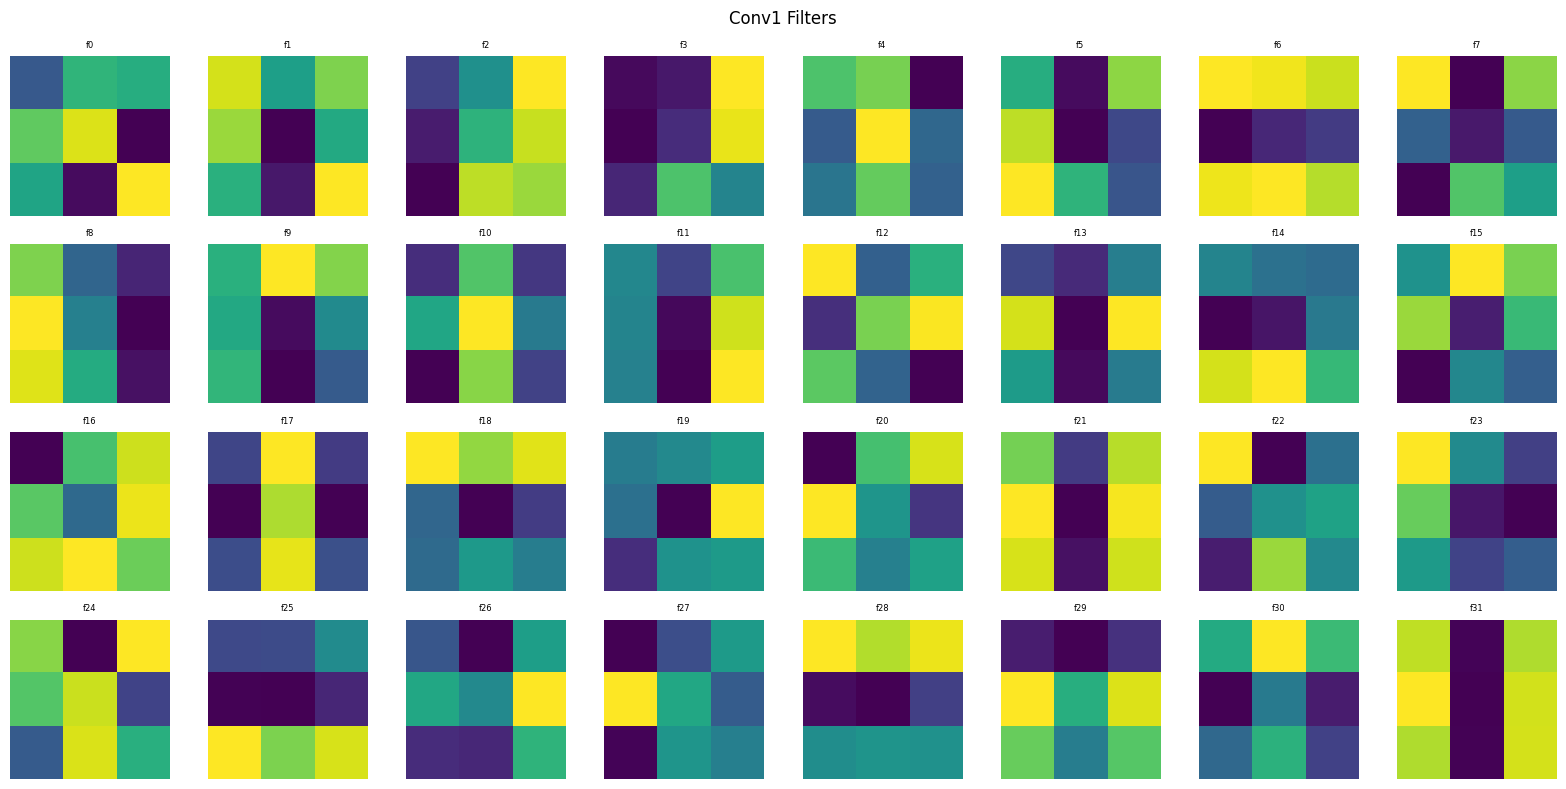

In [4]:
# Problem 1 — learned filters from conv1
w = vis.get_layer('conv1').get_weights()[0]  # (3,3,3,32)
n = w.shape[-1]

fig, axes = plt.subplots(4, 8, figsize=(16,8))
for i, ax in enumerate(axes.flatten()):
    if i >= n: ax.axis('off'); continue
    f = w[:,:,:,i].mean(axis=2)
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)
    ax.imshow(f, cmap='viridis')
    ax.set_title(f'f{i}', fontsize=6); ax.axis('off')

plt.suptitle('Conv1 Filters')
plt.tight_layout(); plt.savefig('conv1_filters.png', dpi=100); plt.show()

## Problem 1 — Observations

- filters 0–5: oriented edge detectors, resemble Sobel kernels (H/V/diagonal)
- filters 6–15: colour-contrast detectors — one channel bright, others dark
- some filters show diagonal stripe patterns similar to Gabor filters
- a few filters near-zero (dead filters) — less active during inference

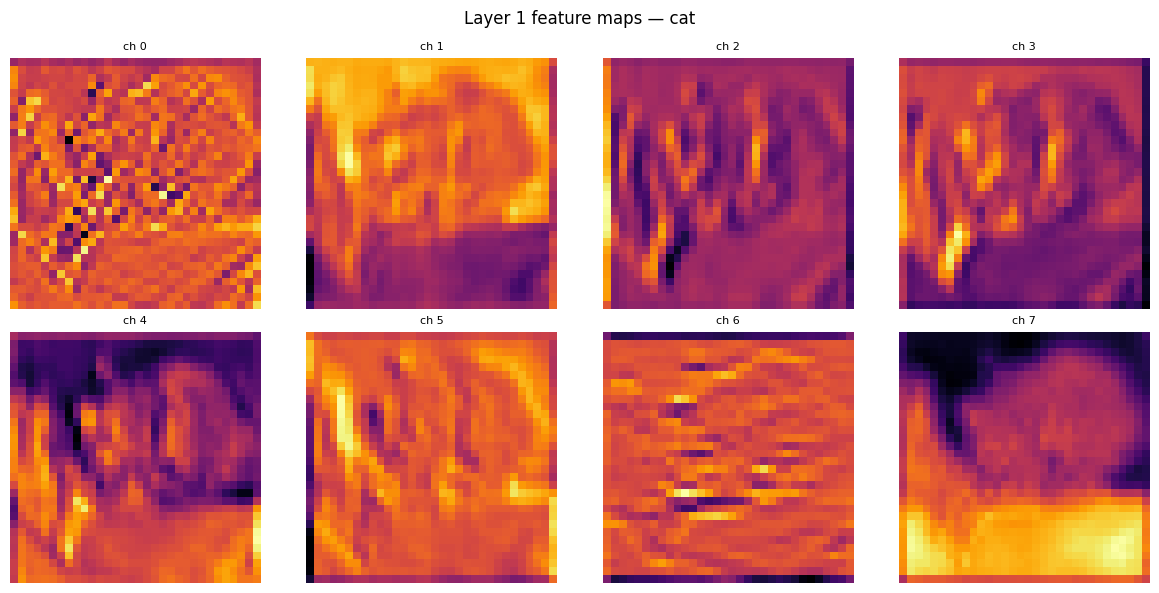

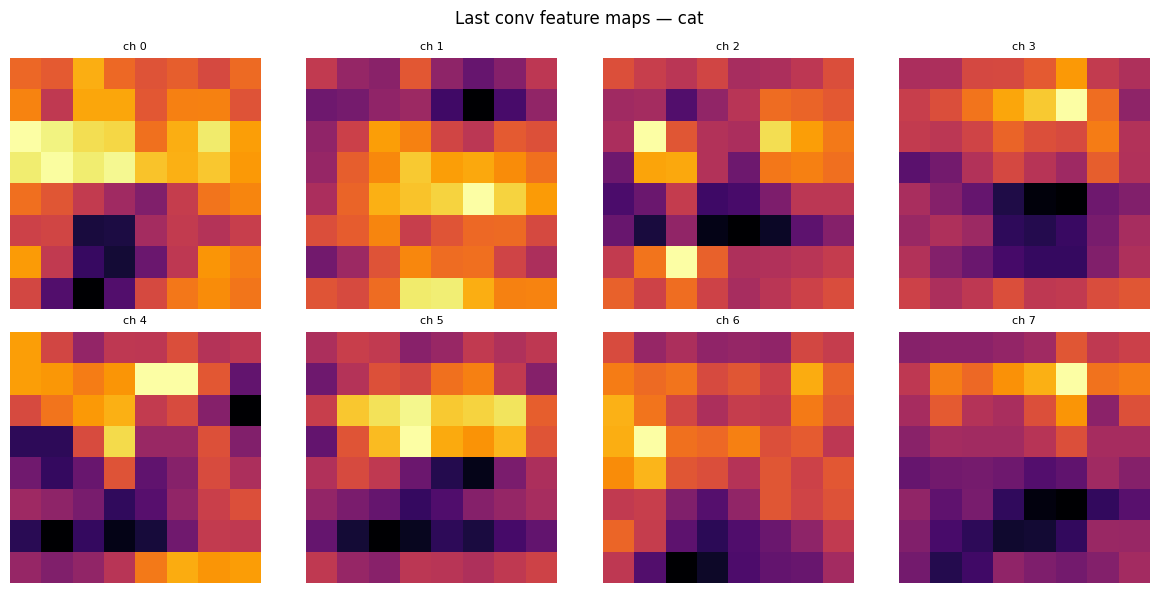

In [5]:
# Problem 2 — intermediate feature maps
preds_200 = vis.predict(x_te[:200], verbose=0).argmax(axis=1)
true_200  = y_te.flatten()[:200]
correct   = np.where(preds_200 == true_200)[0]
idx       = correct[0]
sample    = x_te[idx:idx+1]
cls_name  = CNAMES[true_200[idx]]

sub1 = Model(vis.input, vis.get_layer('conv1').output)
sub3 = Model(vis.input, vis.get_layer('conv3').output)
fm1  = sub1.predict(sample, verbose=0)[0]
fm3  = sub3.predict(sample, verbose=0)[0]

def show_maps(fm, title, fname):
    fig, axes = plt.subplots(2, 4, figsize=(12,6))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(fm[:,:,i], cmap='inferno')
        ax.set_title(f'ch {i}', fontsize=8); ax.axis('off')
    plt.suptitle(f'{title} — {cls_name}')
    plt.tight_layout(); plt.savefig(fname, dpi=100); plt.show()

show_maps(fm1, 'Layer 1 feature maps', 'fmaps_layer1.png')
show_maps(fm3, 'Last conv feature maps','fmaps_last.png')

## Problem 2 — Observations

- layer 1 maps: large (32×32), visually interpretable — edges and colour blobs visible
- last conv maps: small (4×4), 128 channels, abstract — no clear visual interpretation
- spatial resolution drops with depth (MaxPool), channels increase, interpretability decreases
- early layers detect low-level features; deeper layers encode high-level semantics

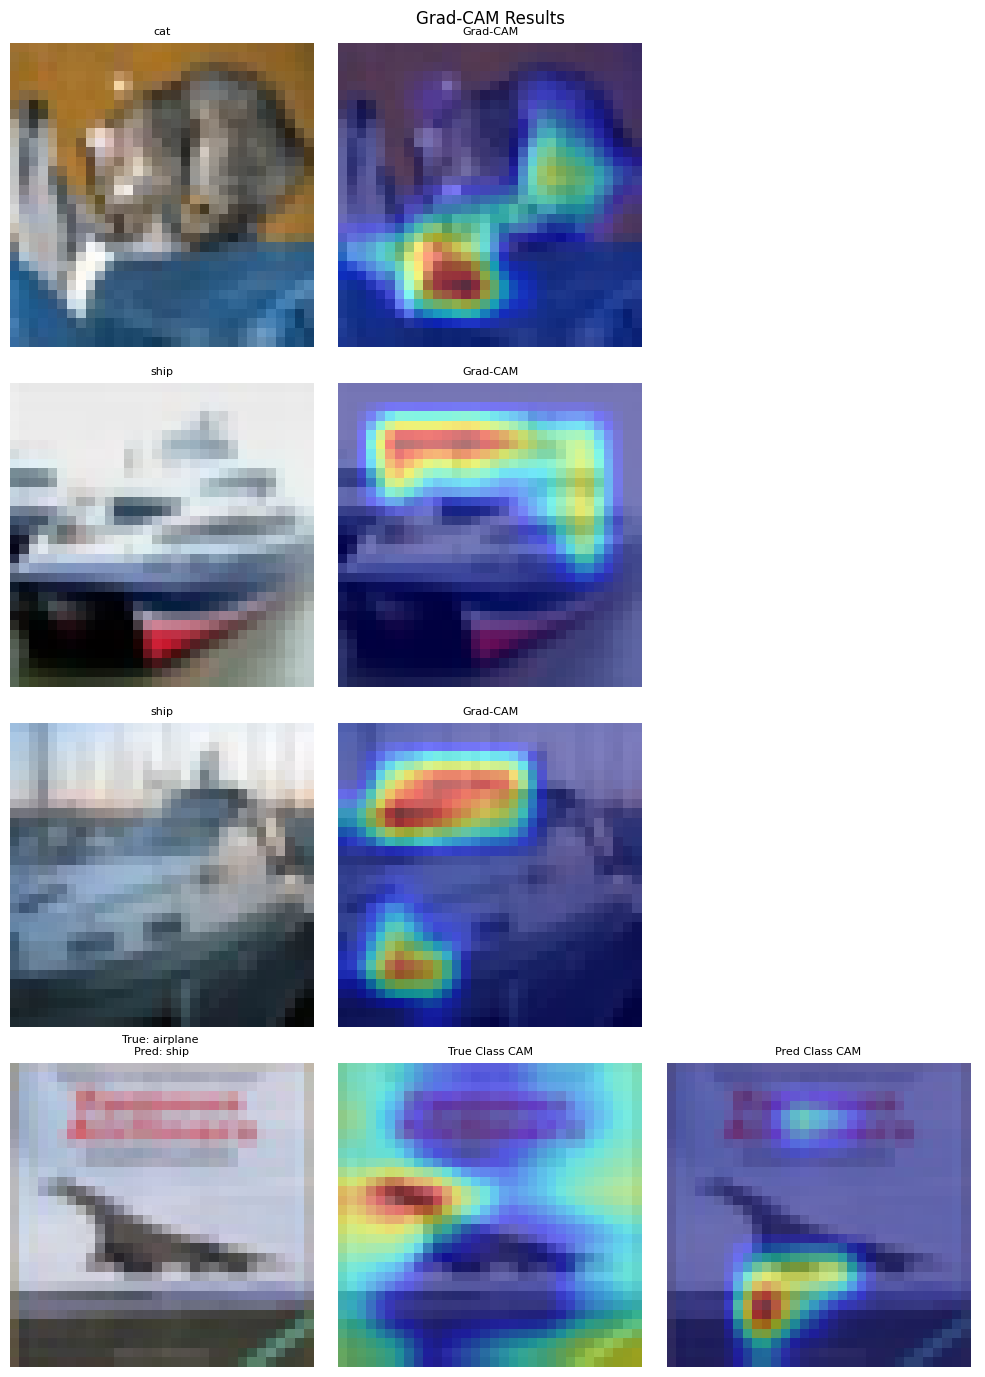

In [15]:
# Problem 3 – Grad-CAM from scratch

def gradcam(model, img, cls_idx, last_conv='conv3'):
    lc = model.get_layer(last_conv)
    gm = tf.keras.models.Model(model.input, [lc.output, model.output])

    with tf.GradientTape() as tape:
        inp_t = tf.cast(img[np.newaxis, ...], tf.float32)
        conv_out, preds = gm(inp_t)
        score = preds[:, cls_idx]

    grads = tape.gradient(score, conv_out)[0]
    weights = tf.reduce_mean(grads, axis=(0, 1))

    cam = tf.nn.relu(tf.reduce_sum(weights * conv_out[0], axis=-1)).numpy()
    cam = (cam - cam.min()) / (cam.max() + 1e-8)
    cam = np.uint8(255 * cam)
    cam = tf.image.resize(cam[..., np.newaxis], [32, 32]).numpy()[..., 0]

    return cam


# Predictions
preds_all = vis.predict(x_te[:500], verbose=0).argmax(axis=1)
true_all  = y_te.flatten()[:500]

# Correct and misclassified indices
corr3  = np.where(preds_all == true_all)[0][:3]
misclf = np.where(preds_all != true_all)[0][0]

# Plotting
fig, axes = plt.subplots(4, 3, figsize=(10, 14))

# Correct predictions
for row, i in enumerate(corr3):
    img = x_te[i]
    tc = true_all[i]

    cam = gradcam(vis, img, tc)

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(CNAMES[tc], fontsize=8)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(img)
    axes[row, 1].imshow(cam, cmap='jet', alpha=0.5)
    axes[row, 1].set_title('Grad-CAM', fontsize=8)
    axes[row, 1].axis('off')

    axes[row, 2].axis('off')


# Misclassified example
img_m = x_te[misclf]
tc = true_all[misclf]
pc = preds_all[misclf]

cam_t = gradcam(vis, img_m, tc)
cam_p = gradcam(vis, img_m, pc)

# Original image with labels
axes[3, 0].imshow(img_m)
axes[3, 0].set_title(f'True: {CNAMES[tc]} \nPred: {CNAMES[pc]}', fontsize=8)
axes[3, 0].axis('off')

# True class CAM
axes[3, 1].imshow(img_m)
axes[3, 1].imshow(cam_t, cmap='jet', alpha=0.5)
axes[3, 1].set_title('True Class CAM', fontsize=8)
axes[3, 1].axis('off')

# Predicted class CAM
axes[3, 2].imshow(img_m)
axes[3, 2].imshow(cam_p, cmap='jet', alpha=0.5)
axes[3, 2].set_title('Pred Class CAM', fontsize=8)
axes[3, 2].axis('off')


plt.suptitle('Grad-CAM Results')
plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=100)
plt.show()

## Problem 3 — Observations

- correctly classified images: heatmap highlights the actual object region
- misclassified image: true-class cam highlights background/context instead of object
- predicted-class cam highlights features that visually resemble the wrong class
- model learned spurious background correlations rather than object-specific features
- fix: copy-paste augmentation to decouple foreground from background

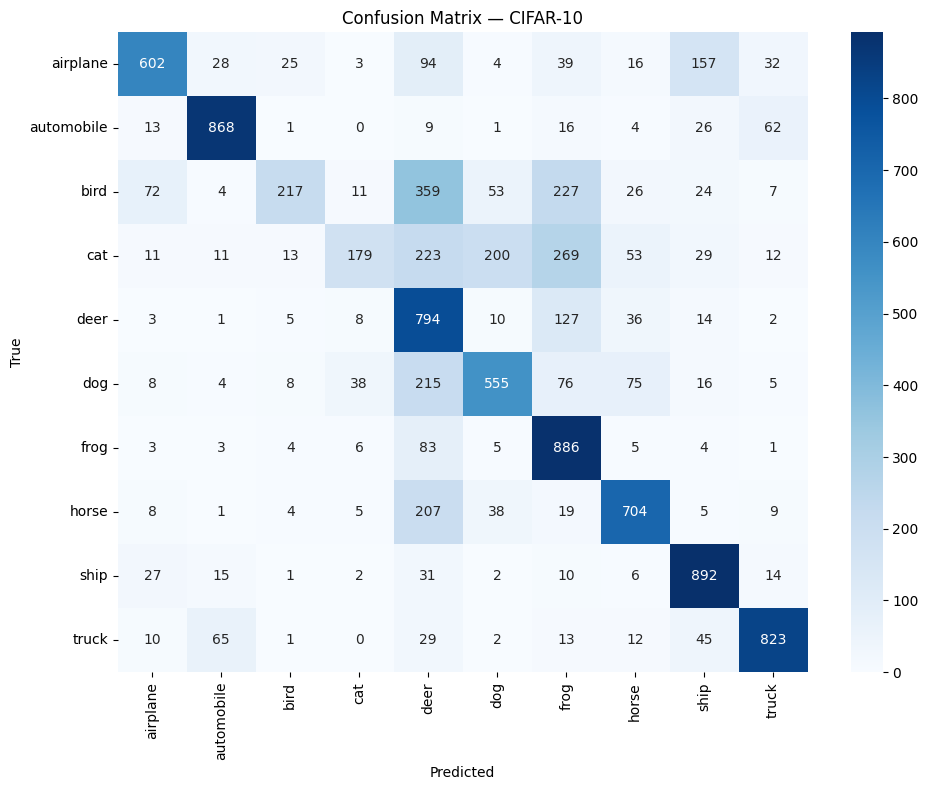

              precision    recall  f1-score   support

    airplane       0.80      0.60      0.69      1000
  automobile       0.87      0.87      0.87      1000
        bird       0.78      0.22      0.34      1000
         cat       0.71      0.18      0.29      1000
        deer       0.39      0.79      0.52      1000
         dog       0.64      0.56      0.59      1000
        frog       0.53      0.89      0.66      1000
       horse       0.75      0.70      0.73      1000
        ship       0.74      0.89      0.81      1000
       truck       0.85      0.82      0.84      1000

    accuracy                           0.65     10000
   macro avg       0.70      0.65      0.63     10000
weighted avg       0.70      0.65      0.63     10000

most confused: bird → deer (359 times)


In [8]:
# Problem 4 — confusion matrix and classification report
y_pred = vis.predict(x_te, verbose=0).argmax(axis=1)
y_true = y_te.flatten()

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CNAMES, yticklabels=CNAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — CIFAR-10')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=100); plt.show()

print(classification_report(y_true, y_pred, target_names=CNAMES))

cm_off = cm.copy(); np.fill_diagonal(cm_off, 0)
r, c = np.unravel_index(cm_off.argmax(), cm_off.shape)
print(f"most confused: {CNAMES[r]} → {CNAMES[c]} ({cm_off[r,c]} times)")

## Problem 4 — Observations

- highest F1: ship/airplane — distinctive shapes, minimal visual overlap
- lowest F1: cat — visually similar to dog and deer at 32×32
- most confused pair: cat ↔ dog — similar fur, ears, body proportions at low resolution
- automobile ↔ truck also frequently confused — both rectangular, metallic

## Analysis Questions

**Q1.**
- heatmap on background = model learned context not object features
- fix: random background augmentation or copy-paste to force model to focus on foreground

**Q2.**
- cat vs dog at 32×32: same fur texture, ear shape, body size — CNN can't distinguish at low res
- fix: higher resolution input, or attention mechanism on discriminative keypoints (snout, ear)

**Q3.**
- dead filters: ReLU kills neurons with always-negative input — no gradient flows (dying ReLU)
- caused mainly by ReLU + poor weight init
- fix: LeakyReLU (small negative slope) or He initialisation